Task 2.1 Initial model development 
Develop a baseline ANN to predict Soil Organic Carbon (soil_organic_carbon_target) 
using a single hidden layer with 32 neurons with ReLU activation function.  
Compile the model using: 
• Loss Function: Mean Squared Error (MSE)  
• Optimizer: Adam (default learning rate)  
• Evaluation Metric: Mean Absolute Error (MAE)  
Train the model using: 
• Epochs: 100  
• Batch size: 32  
• Validation set: created in Part 1  
Set a random seed prior to training to ensure your results are reproducible. 

In [1]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import Perceptron

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    multilabel_confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error, 
    root_mean_squared_error, 
    r2_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.feature_selection import f_classif

import tensorflow as tf
import tensorflow.keras.backend as K


Read the dataset

In [2]:
# Read the dataset
df = pd.read_csv("../data/NZ_LUCAS_SMAP_NIWA.csv")

Even task 1's work shows that some of the attributes might have more correlation on the target attributes than others, I still run the model with all the attribues because when I tried to run the model with only the correlated attributed, the model does not produce very good R2-Score so I choose to run all the attributes 

separates input features (X) and target labels (y) and then, it splits dataset into three datasets: training dataset, test dataset and validation dataset 60%:20%:20% with the ratio 60% : 20% : 20%.  The datasets are scaled to prepare for the analysis. I also have a fix seed to make sure the results are can be produced the same. 

In [3]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

LabelEncoder

import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, SGD, Adagrad, RMSprop, Adadelta
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.models import Sequential

from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier

from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import numpy as np

import time
import keras_tuner as kt


In [4]:
import random

# Fix seeds for reproducibility
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

# Separate input features (X) and target labels (y)
X = df.drop(columns=['soil_organic_carbon_target', '36']).values # Input features
y = df['soil_organic_carbon_target'].values.reshape(-1, 1) # Target labels

# Splitting the dataset into three datasets for training, testing and validation with the ratio 60% : 20% : 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=seed)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=seed)

# Scaling data
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)
X_val_scaled  = scaler_X.transform(X_val)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

Below is the baseline model: 

In [5]:
### Gradient Descent
# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with five neurons using ReLU activation function, and output layer which uses linear activation function to calculate output
gd_model = Sequential([
    Input(shape=(35,)),
    Dense(32, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)), 
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = Adam(learning_rate=0.001)

gd_model.compile(
    optimizer=opt,
    loss="mse",
    metrics=["mae"]
)


start_time = time.time()

# Train the model with train dataset and validate the model using validation dataset during training
history_gd = gd_model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1
)

end_time = time.time()
gd_training_time = end_time - start_time

print(f"Training time: {gd_training_time:.2f} seconds")
print(f"Training time: {gd_training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6322 - mae: 0.6228 - val_loss: 0.3011 - val_mae: 0.4434
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2239 - mae: 0.3770 - val_loss: 0.2174 - val_mae: 0.3725
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1935 - mae: 0.3498 - val_loss: 0.2062 - val_mae: 0.3629
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1827 - mae: 0.3394 - val_loss: 0.1987 - val_mae: 0.3564
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1755 - mae: 0.3321 - val_loss: 0.1941 - val_mae: 0.3526
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1706 - mae: 0.3269 - val_loss: 0.1915 - val_mae: 0.3509
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1673 - mae: 0.3235 - val_loss: 0.1899 - val_mae: 0.3495
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1648 - mae: 0.3211 - val_loss: 0.1894 - val_mae: 0.3491
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.162

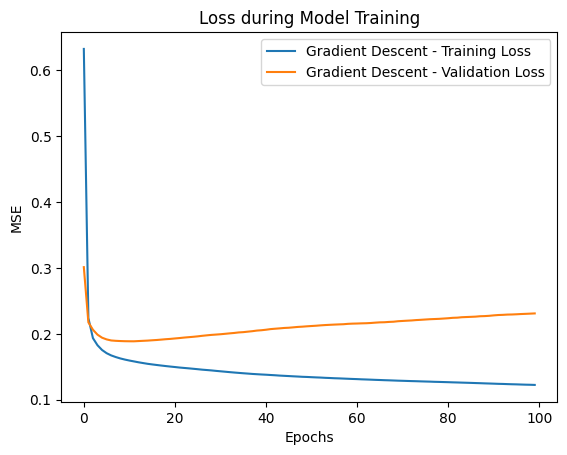

In [37]:
# Plot the training and validation accuracy and loss
plt.plot(history_gd.history["loss"], label="Gradient Descent - Training Loss")
plt.plot(history_gd.history["val_loss"], label="Gradient Descent - Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Loss during Model Training")
plt.legend()
plt.show()

In the next step, I will try to tune the model with different layers from 1 to 4

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9471 - mae: 0.7711 - val_loss: 0.6344 - val_mae: 0.6372
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5125 - mae: 0.5658 - val_loss: 0.4007 - val_mae: 0.5120
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3371 - mae: 0.4587 - val_loss: 0.3020 - val_mae: 0.4444
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2622 - mae: 0.4063 - val_loss: 0.2568 - val_mae: 0.4075
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2278 - mae: 0.3792 - val_loss: 0.2351 - val_mae: 0.3884
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2111 - mae: 0.3652 - val_loss: 0.2241 - val_mae: 0.3784
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2023 - mae: 0.3578 - val_loss: 0.2178 - val_mae: 0.3722
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1970 - mae: 0.3530 - val_loss: 0.2135 - val_mae: 0.3680
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.193

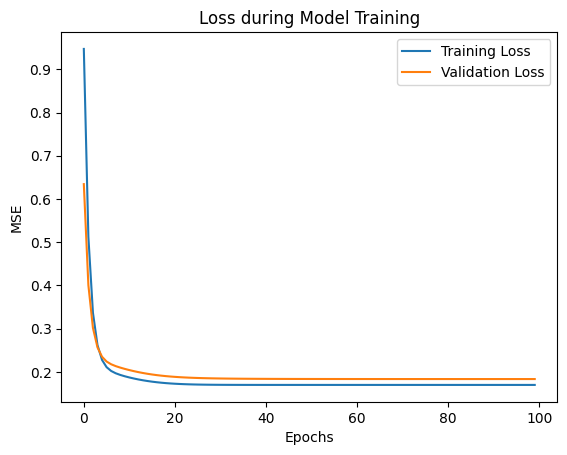

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6322 - mae: 0.6228 - val_loss: 0.3011 - val_mae: 0.4434
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2239 - mae: 0.3770 - val_loss: 0.2174 - val_mae: 0.3725
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1935 - mae: 0.3498 - val_loss: 0.2062 - val_mae: 0.3629
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1827 - mae: 0.3394 - val_loss: 0.1987 - val_mae: 0.3564
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1755 - mae: 0.3321 - val_loss: 0.1941 - val_mae: 0.3526
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1706 - mae: 0.3269 - val_loss: 0.1915 - val_mae: 0.3509
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1673 - mae: 0.3235 - val_loss: 0.1899 - val_mae: 0.3495
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1648 - mae: 0.3211 - val_loss: 0.1894 - val_mae: 0.3491
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.162

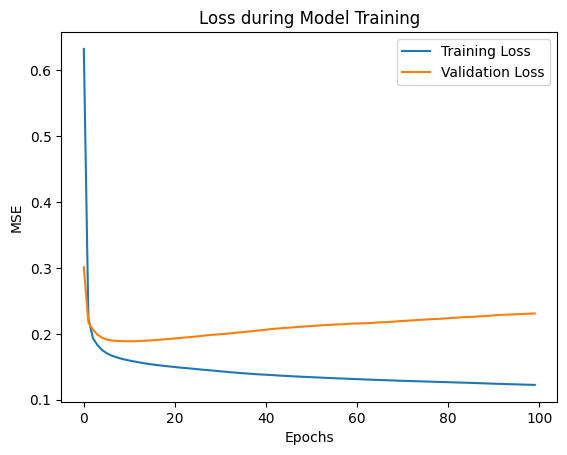

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6611 - mae: 0.6338 - val_loss: 0.2518 - val_mae: 0.4002
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2126 - mae: 0.3682 - val_loss: 0.2100 - val_mae: 0.3672
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1885 - mae: 0.3453 - val_loss: 0.1993 - val_mae: 0.3582
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1783 - mae: 0.3354 - val_loss: 0.1947 - val_mae: 0.3545
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1725 - mae: 0.3295 - val_loss: 0.1925 - val_mae: 0.3525
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1688 - mae: 0.3257 - val_loss: 0.1918 - val_mae: 0.3517
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1659 - mae: 0.3229 - val_loss: 0.1913 - val_mae: 0.3512
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1634 - mae: 0.3204 - val_loss: 0.1916 - val_mae: 0.3512
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.161

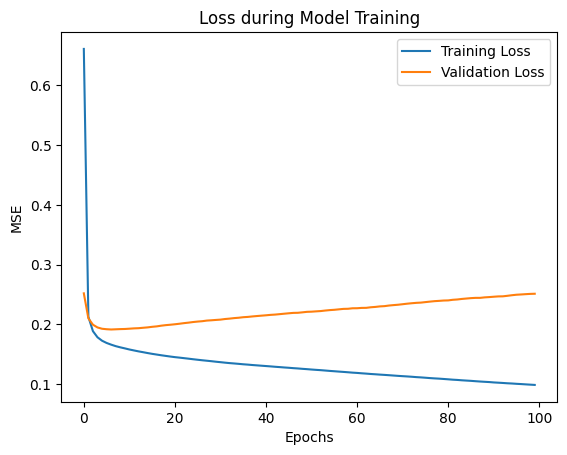

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7688 - mae: 0.6836 - val_loss: 0.2740 - val_mae: 0.4149
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2203 - mae: 0.3736 - val_loss: 0.2116 - val_mae: 0.3669
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1909 - mae: 0.3472 - val_loss: 0.2005 - val_mae: 0.3576
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1802 - mae: 0.3368 - val_loss: 0.1960 - val_mae: 0.3542
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1743 - mae: 0.3312 - val_loss: 0.1943 - val_mae: 0.3530
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1704 - mae: 0.3275 - val_loss: 0.1941 - val_mae: 0.3529
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1673 - mae: 0.3246 - val_loss: 0.1946 - val_mae: 0.3534
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1650 - mae: 0.3223 - val_loss: 0.1957 - val_mae: 0.3540
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.162

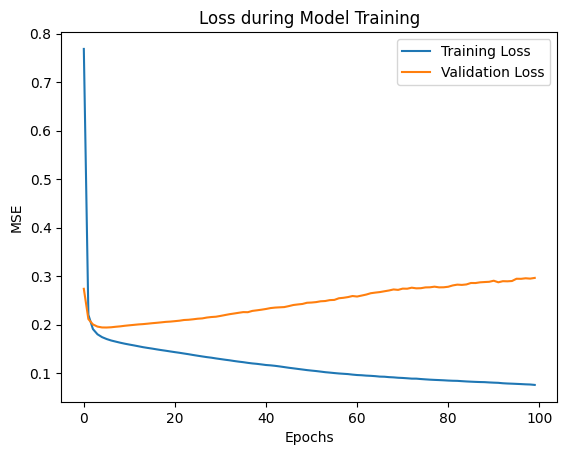

In [39]:
histories = {}
n_layers = [1,2,3,4]




for no_of_layers in n_layers:
# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with one neuron, and output layer which uses linear activation function to calculate output
    
    model = Sequential([
    Input(shape=(35,))])

    for i in range(1,no_of_layers):
        model.add(Dense(32, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))) 

    model.add(Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)))
    

    
    opt = Adam(learning_rate=0.001)

    model.compile(
        optimizer=opt,
        loss='mse',
        metrics=['mae']
)

    # Train the model using GD with train dataset and validate the model using validation dataset during training
    start_time = time.time()

    history_model = model.fit(
        X_train_scaled,
        y_train_scaled,
        epochs=100,
        batch_size=32, # batch_size > training_dataset_size --> use GD
        validation_data=(X_val_scaled, y_val_scaled),
        verbose=1
    )

    end_time = time.time()
    training_time = end_time - start_time

 


    
    histories[no_of_layers] = history_model

    # make Predictions using the Model
    y_true = y_test
    y_pred = np.argmax(model.predict(X_test_scaled), axis=1) # convert probabilities to class labels

    y_prob = model.predict(X_test_scaled)
    
    print('-----------------------------------------------------------------------------------------------------------------------')
    print('The results with %f no. of layers', no_of_layers)
    print('-----------------------------------------------------------------------------------------------------------------------')

   
   
   # Plot the training and validation accuracy and loss
    plt.plot(history_model.history["loss"], label="Training Loss")
    plt.plot(history_model.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("MSE")
    plt.title("Loss during Model Training")
    plt.legend()
    plt.show()

  










From the analysis above, when the layers increase from 1 to 4, loweset msa and mae are at 2 layers, so I will keep at two hidden layer. In the next step I will investigate the effect of varying the number of neurons per hidden layers. I will try with 16, 32, 64 and 128 neurons. 

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8521 - mae: 0.7271 - val_loss: 0.4426 - val_mae: 0.5350
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2603 - mae: 0.4067 - val_loss: 0.2320 - val_mae: 0.3849
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2024 - mae: 0.3589 - val_loss: 0.2129 - val_mae: 0.3695
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1882 - mae: 0.3451 - val_loss: 0.2029 - val_mae: 0.3608
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1798 - mae: 0.3366 - val_loss: 0.1970 - val_mae: 0.3561
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1747 - mae: 0.3314 - val_loss: 0.1938 - val_mae: 0.3535
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1713 - mae: 0.3280 - val_loss: 0.1918 - val_mae: 0.3514
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1689 - mae: 0.3255 - val_loss: 0.1906 - val_mae: 0.3500
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.167

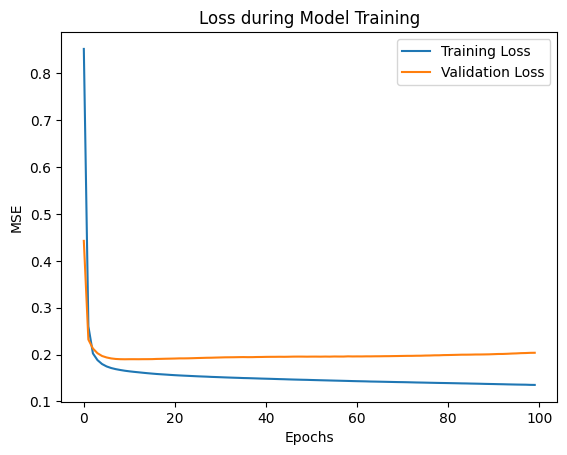

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6611 - mae: 0.6338 - val_loss: 0.2518 - val_mae: 0.4002
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2126 - mae: 0.3682 - val_loss: 0.2100 - val_mae: 0.3672
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1885 - mae: 0.3453 - val_loss: 0.1993 - val_mae: 0.3582
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1783 - mae: 0.3354 - val_loss: 0.1947 - val_mae: 0.3545
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1725 - mae: 0.3295 - val_loss: 0.1925 - val_mae: 0.3525
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1688 - mae: 0.3257 - val_loss: 0.1918 - val_mae: 0.3517
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1659 - mae: 0.3229 - val_loss: 0.1913 - val_mae: 0.3512
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1634 - mae: 0.3204 - val_loss: 0.1916 - val_mae: 0.3512
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.161

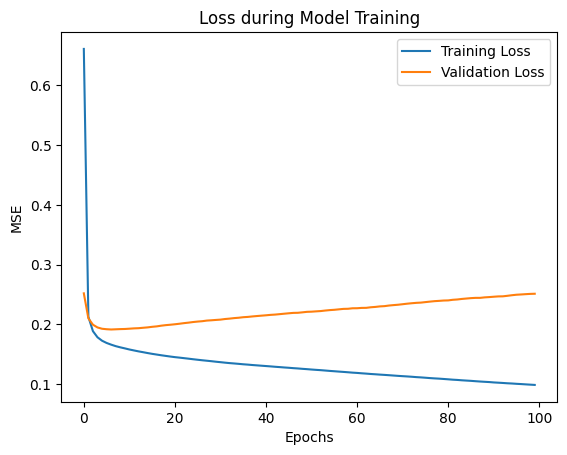

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5056 - mae: 0.5462 - val_loss: 0.2328 - val_mae: 0.3823
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2008 - mae: 0.3564 - val_loss: 0.2068 - val_mae: 0.3624
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1799 - mae: 0.3357 - val_loss: 0.2010 - val_mae: 0.3577
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1709 - mae: 0.3266 - val_loss: 0.2003 - val_mae: 0.3572
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1654 - mae: 0.3210 - val_loss: 0.2004 - val_mae: 0.3571
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1611 - mae: 0.3167 - val_loss: 0.2010 - val_mae: 0.3573
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1579 - mae: 0.3135 - val_loss: 0.2020 - val_mae: 0.3578
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1550 - mae: 0.3107 - val_loss: 0.2035 - val_mae: 0.3589
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.152

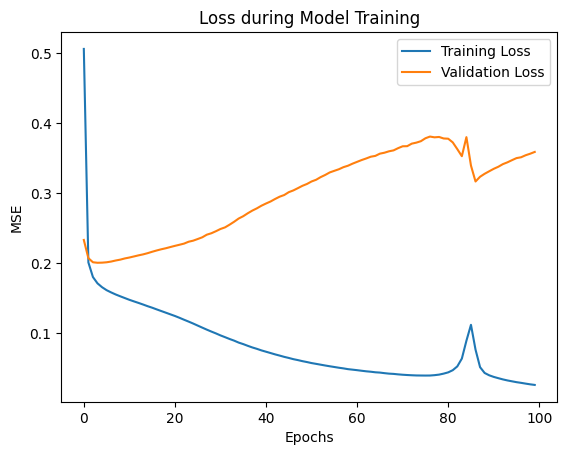

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3663 - mae: 0.4678 - val_loss: 0.2152 - val_mae: 0.3699
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1886 - mae: 0.3446 - val_loss: 0.2026 - val_mae: 0.3594
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1740 - mae: 0.3299 - val_loss: 0.2011 - val_mae: 0.3582
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1653 - mae: 0.3211 - val_loss: 0.2016 - val_mae: 0.3588
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1586 - mae: 0.3142 - val_loss: 0.2035 - val_mae: 0.3605
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1526 - mae: 0.3083 - val_loss: 0.2055 - val_mae: 0.3623
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1470 - mae: 0.3026 - val_loss: 0.2086 - val_mae: 0.3652
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1410 - mae: 0.2962 - val_loss: 0.2121 - val_mae: 0.3685
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.134

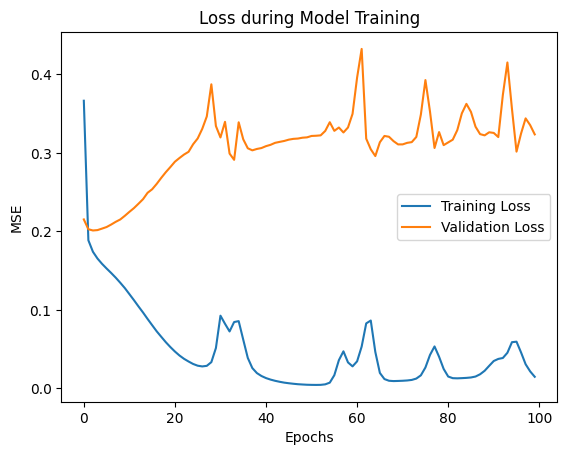

In [40]:
histories = {}
n_neuron = [16,32,64,128]




for no_of_neuron in n_neuron:
# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with one neuron, and output layer which uses linear activation function to calculate output
    
    model = Sequential([
    Input(shape=(35,))])

    model.add(Dense(no_of_neuron, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))) 
    model.add(Dense(no_of_neuron, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))) 

    model.add(Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)))
    

    
    opt = Adam(learning_rate=0.001)

    model.compile(
        optimizer=opt,
        loss='mse',
        metrics=['mae']
)

    # Train the model using GD with train dataset and validate the model using validation dataset during training
    start_time = time.time()

    history_model = model.fit(
        X_train_scaled,
        y_train_scaled,
        epochs=100,
        batch_size=32, # batch_size > training_dataset_size --> use GD
        validation_data=(X_val_scaled, y_val_scaled),
        verbose=1
    )

    end_time = time.time()
    training_time = end_time - start_time

 


    
    histories[no_of_neuron] = history_model

    # make Predictions using the Model
    y_true = y_test
    y_pred = np.argmax(model.predict(X_test_scaled), axis=1) # convert probabilities to class labels

    y_prob = model.predict(X_test_scaled)
    
    print('-----------------------------------------------------------------------------------------------------------------------')
    print('The results with %f no. of neuron', no_of_neuron)
    print('-----------------------------------------------------------------------------------------------------------------------')

   
   
   # Plot the training and validation accuracy and loss
    plt.plot(history_model.history["loss"], label="Training Loss")
    plt.plot(history_model.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("MSE")
    plt.title("Loss during Model Training")
    plt.legend()
    plt.show()

  










So, we can see that with no of neuron being 16 we have the least mse and mae. So we will choose the model with two layers and 16 neurons. In the next step, we will use this best architecture so far to evaluate the effect of different activation 
functions. I will test the following activation fuctions: ReLU, tanh, and sigmoid

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8521 - mae: 0.7271 - val_loss: 0.4426 - val_mae: 0.5350
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2603 - mae: 0.4067 - val_loss: 0.2320 - val_mae: 0.3849
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2024 - mae: 0.3589 - val_loss: 0.2129 - val_mae: 0.3695
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1882 - mae: 0.3451 - val_loss: 0.2029 - val_mae: 0.3608
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1798 - mae: 0.3366 - val_loss: 0.1970 - val_mae: 0.3561
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1747 - mae: 0.3314 - val_loss: 0.1938 - val_mae: 0.3535
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1713 - mae: 0.3280 - val_loss: 0.1918 - val_mae: 0.3514
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1689 - mae: 0.3255 - val_loss: 0.1906 - val_mae: 0.3500
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.167

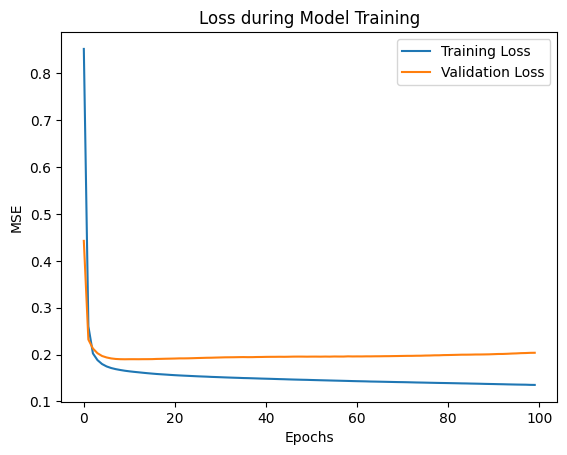

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6645 - mae: 0.6338 - val_loss: 0.2674 - val_mae: 0.4110
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2243 - mae: 0.3755 - val_loss: 0.2169 - val_mae: 0.3707
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2024 - mae: 0.3547 - val_loss: 0.2017 - val_mae: 0.3578
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1925 - mae: 0.3456 - val_loss: 0.1951 - val_mae: 0.3524
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1884 - mae: 0.3416 - val_loss: 0.1924 - val_mae: 0.3503
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1863 - mae: 0.3397 - val_loss: 0.1910 - val_mae: 0.3493
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1849 - mae: 0.3384 - val_loss: 0.1902 - val_mae: 0.3487
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1838 - mae: 0.3374 - val_loss: 0.1897 - val_mae: 0.3483
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.182

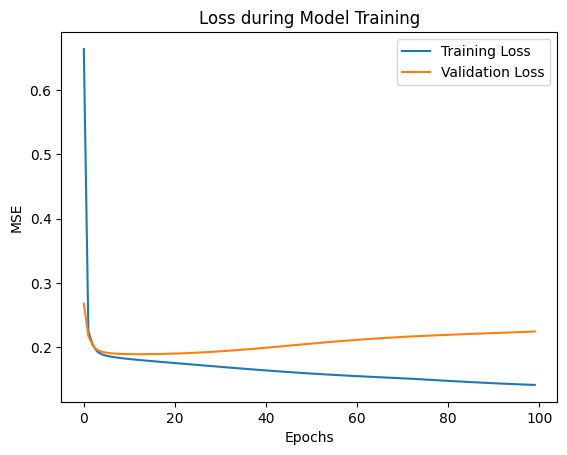

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9939 - mae: 0.7934 - val_loss: 0.9359 - val_mae: 0.7675
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9045 - mae: 0.7546 - val_loss: 0.7376 - val_mae: 0.6830
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5484 - mae: 0.5767 - val_loss: 0.3699 - val_mae: 0.4808
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3070 - mae: 0.4300 - val_loss: 0.2750 - val_mae: 0.4155
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2620 - mae: 0.3990 - val_loss: 0.2552 - val_mae: 0.4012
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2467 - mae: 0.3878 - val_loss: 0.2416 - val_mae: 0.3908
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2349 - mae: 0.3783 - val_loss: 0.2304 - val_mae: 0.3822
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2251 - mae: 0.3703 - val_loss: 0.2211 - val_mae: 0.3747
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.217

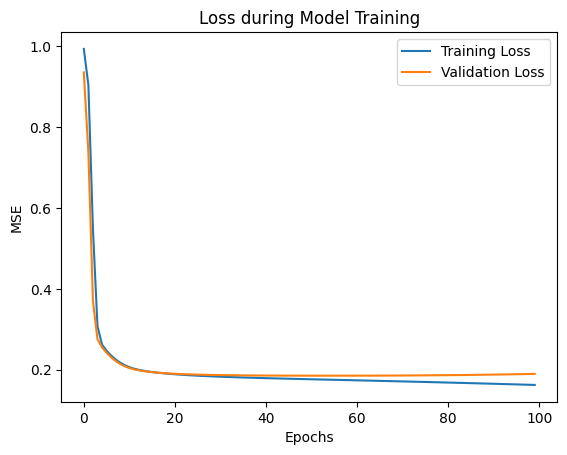

In [41]:
histories = {}
activation_function = ['relu','tanh','sigmoid']




for activation in activation_function:
# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with one neuron, and output layer which uses linear activation function to calculate output
    
    model = Sequential([
    Input(shape=(35,))])

    model.add(Dense(16, activation=activation, kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)))

    model.add(Dense(16, activation=activation, kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)))  

    model.add(Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)))
    

    
    opt = Adam(learning_rate=0.001)

    model.compile(
        optimizer=opt,
        loss='mse',
        metrics=['mae']
)

    # Train the model using GD with train dataset and validate the model using validation dataset during training
    start_time = time.time()

    history_model = model.fit(
        X_train_scaled,
        y_train_scaled,
        epochs=100,
        batch_size=32, # batch_size > training_dataset_size --> use GD
        validation_data=(X_val_scaled, y_val_scaled),
        verbose=1
    )

    end_time = time.time()
    training_time = end_time - start_time

 


    
    histories[activation] = history_model

    # make Predictions using the Model
    y_true = y_test
    y_pred = np.argmax(model.predict(X_test_scaled), axis=1) # convert probabilities to class labels

    y_prob = model.predict(X_test_scaled)
    
    print('-----------------------------------------------------------------------------------------------------------------------')
    print('The results with %f activation function', activation)
    print('-----------------------------------------------------------------------------------------------------------------------')

   
   
   # Plot the training and validation accuracy and loss
    plt.plot(history_model.history["loss"], label="Training Loss")
    plt.plot(history_model.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("MSE")
    plt.title("Loss during Model Training")
    plt.legend()
    plt.show()

  










So we can see that the acivation of tanh gives us the lowest mae amd loss so we will use tanh as the activation. So our best model so far has two hidden layer, 16 neurons and activation of tanh. 

In [42]:
### Gradient Descent
# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with five neurons using ReLU activation function, and output layer which uses linear activation function to calculate output
gd_model = Sequential([
    Input(shape=(35,)),
    Dense(16, activation='tanh', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)), 

    Dense(16, activation='tanh', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),

    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = Adam(learning_rate=0.001)

gd_model.compile(
    optimizer=opt,
    loss="mse",
    metrics=["mae"]
)

start_time = time.time()

# Train the model using GD with train dataset and validate the model using validation dataset during training
history_gd = gd_model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1
)

end_time = time.time()
gd_training_time = end_time - start_time

print(f"Training time: {gd_training_time:.2f} seconds")
print(f"Training time: {gd_training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6645 - mae: 0.6338 - val_loss: 0.2674 - val_mae: 0.4110
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2243 - mae: 0.3755 - val_loss: 0.2169 - val_mae: 0.3707
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2024 - mae: 0.3547 - val_loss: 0.2017 - val_mae: 0.3578
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1925 - mae: 0.3456 - val_loss: 0.1951 - val_mae: 0.3524
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1884 - mae: 0.3416 - val_loss: 0.1924 - val_mae: 0.3503
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1863 - mae: 0.3397 - val_loss: 0.1910 - val_mae: 0.3493
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1849 - mae: 0.3384 - val_loss: 0.1902 - val_mae: 0.3487
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1838 - mae: 0.3374 - val_loss: 0.1897 - val_mae: 0.3483
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.182

In the next step I will investigate the effect of different optimisation algorithms, including appropriate 
tuning of their associated hyperparameters. There are three optimisation algorithms that I will investigate. They are Adam, Adagrad, RMSprob. First we check with Adam optimiser. 

First I try with Adam learning rate 0.01

In [44]:



# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with one neuron, and output layer which uses linear activation function to calculate output
model_adam_001 = Sequential([
    Input(shape=(35,)),
    Dense(16, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)), 
    Dense(16, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = Adam(learning_rate=0.01)

model_adam_001.compile(
    optimizer=opt,
    loss="mse",
    metrics=['mae']
)

# Train the model using GD with train dataset and validate the model using validation dataset during training
start_time = time.time()

history_adam_001 = model_adam_001.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3223 - mae: 0.4392 - val_loss: 0.2160 - val_mae: 0.3733
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1964 - mae: 0.3521 - val_loss: 0.2080 - val_mae: 0.3661
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1881 - mae: 0.3437 - val_loss: 0.2058 - val_mae: 0.3652
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1824 - mae: 0.3382 - val_loss: 0.2061 - val_mae: 0.3668
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1776 - mae: 0.3338 - val_loss: 0.2066 - val_mae: 0.3681
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1725 - mae: 0.3292 - val_loss: 0.2083 - val_mae: 0.3696
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1691 - mae: 0.3259 - val_loss: 0.2103 - val_mae: 0.3709
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1673 - mae: 0.3239 - val_loss: 0.2121 - val_mae: 0.3727
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.165

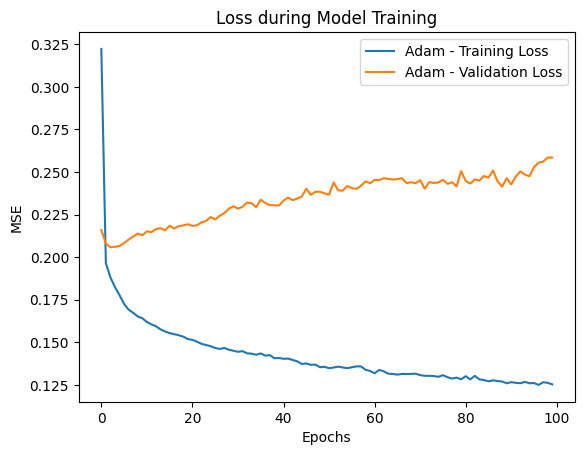

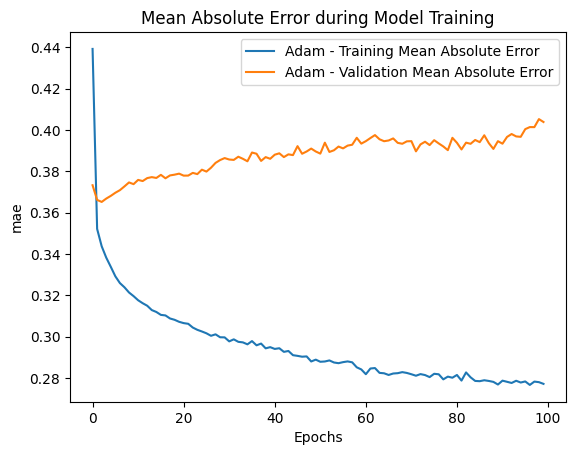

In [45]:
# Plot the training and validation accuracy and loss
plt.plot(history_adam_001.history["loss"], label="Adam - Training Loss")
plt.plot(history_adam_001.history["val_loss"], label="Adam - Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Loss during Model Training")
plt.legend()
plt.show()

plt.plot(history_adam_001.history["mae"], label="Adam - Training Mean Absolute Error")
plt.plot(history_adam_001.history["val_mae"], label="Adam - Validation Mean Absolute Error")
plt.xlabel("Epochs")
plt.ylabel("mae")
plt.title("Mean Absolute Error during Model Training")
plt.legend()
plt.show()

So we can see that with Adam optimizer learning rate 0.01 val_mae and val_loss are quite high

In the next step, I tried adam optimizer with a smaller learning rate which is 0.001 

In [46]:



# Create a sequential model with input layer which takes the values of 35 input parameters as input, two hidden layers with 16 neuron, and output layer which uses linear activation function to calculate output
model_adam_0001 = Sequential([
    Input(shape=(35,)),
    Dense(16, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    Dense(16, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),  
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = Adam(learning_rate=0.001)

model_adam_0001.compile(
    optimizer=opt,
    loss="mse",
    metrics=['mae']
)

# Train the model using GD with train dataset and validate the model using validation dataset during training
start_time = time.time()

history_adam_0001 = model_adam_0001.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8521 - mae: 0.7271 - val_loss: 0.4426 - val_mae: 0.5350
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2603 - mae: 0.4067 - val_loss: 0.2320 - val_mae: 0.3849
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2024 - mae: 0.3589 - val_loss: 0.2129 - val_mae: 0.3695
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1882 - mae: 0.3451 - val_loss: 0.2029 - val_mae: 0.3608
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1798 - mae: 0.3366 - val_loss: 0.1970 - val_mae: 0.3561
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1747 - mae: 0.3314 - val_loss: 0.1938 - val_mae: 0.3535
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1713 - mae: 0.3280 - val_loss: 0.1918 - val_mae: 0.3514
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1689 - mae: 0.3255 - val_loss: 0.1906 - val_mae: 0.3500
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.167

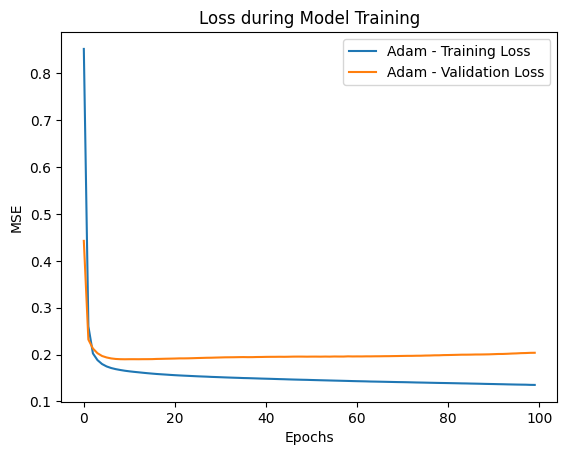

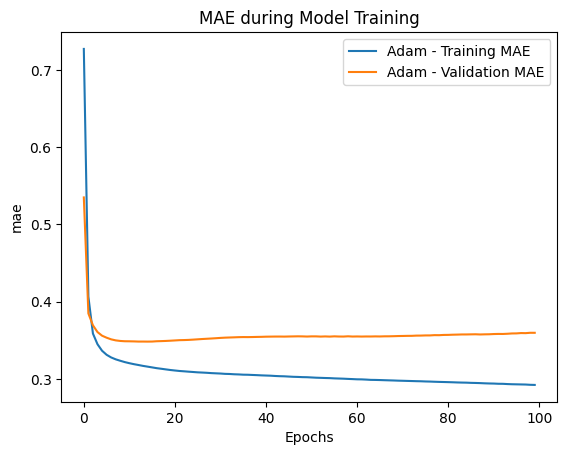

In [47]:
# Plot the training and validation Mae and loss
plt.plot(history_adam_0001.history["loss"], label="Adam - Training Loss")
plt.plot(history_adam_0001.history["val_loss"], label="Adam - Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Loss during Model Training")
plt.legend()
plt.show()

plt.plot(history_adam_0001.history["mae"], label="Adam - Training MAE")
plt.plot(history_adam_0001.history["val_mae"], label="Adam - Validation MAE")
plt.xlabel("Epochs")
plt.ylabel("mae")
plt.title("MAE during Model Training")
plt.legend()
plt.show()

With adam with learning rate of 0.001, we can see that the R2_score train and validation both higher than Adam learning rate of 0.01. We will test the model with learning rate even smaller 0.0001 to chekc if we can have the score higher. 

In [48]:


# Create a sequential model with input layer which takes the values of 35 input parameters as input, 2 hidden layers with 16 neurons, and output layer which uses linear activation function to calculate output
model_adam_00001 = Sequential([
    Input(shape=(35,)),
    Dense(16, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    Dense(16, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)), 
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = Adam(learning_rate=0.0001)

model_adam_00001.compile(
    optimizer=opt,
    loss="mse",
    metrics=['mae']
)

# Train the model using GD with train dataset and validate the model using validation dataset during training
start_time = time.time()

history_adam_00001 = model_adam_00001.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9977 - mae: 0.7950 - val_loss: 0.9541 - val_mae: 0.7760
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9919 - mae: 0.7926 - val_loss: 0.9462 - val_mae: 0.7729
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9771 - mae: 0.7865 - val_loss: 0.9258 - val_mae: 0.7649
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9413 - mae: 0.7714 - val_loss: 0.8803 - val_mae: 0.7468
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8725 - mae: 0.7416 - val_loss: 0.8016 - val_mae: 0.7137
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7707 - mae: 0.6951 - val_loss: 0.6979 - val_mae: 0.6674
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6524 - mae: 0.6373 - val_loss: 0.5872 - val_mae: 0.6134
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5381 - mae: 0.5768 - val_loss: 0.4874 - val_mae: 0.5599
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.441

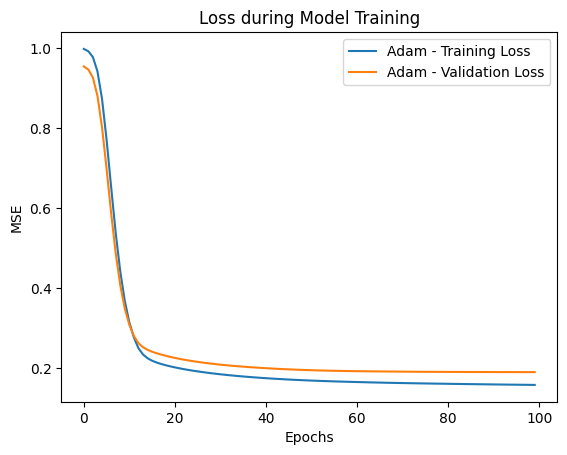

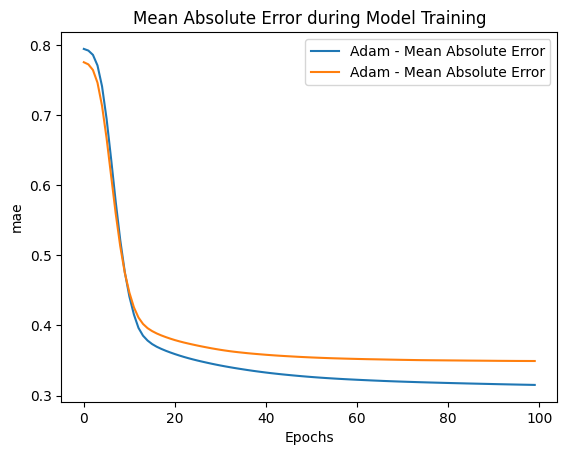

In [49]:
# Plot the training and validation MAE and loss
plt.plot(history_adam_00001.history["loss"], label="Adam - Training Loss")
plt.plot(history_adam_00001.history["val_loss"], label="Adam - Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Loss during Model Training")
plt.legend()
plt.show()

plt.plot(history_adam_00001.history["mae"], label="Adam - Mean Absolute Error")
plt.plot(history_adam_00001.history["val_mae"], label="Adam - Mean Absolute Error")
plt.xlabel("Epochs")
plt.ylabel("mae")
plt.title("Mean Absolute Error during Model Training")
plt.legend()
plt.show()

We can see that with the learning rate of 0.0001, the mean absolute error and loss of val_date and train_data are smaller. Therefore, I will do another ADam optimizer with learning rate of 0.00001 

In [50]:



# Create a sequential model with input layer which takes the values of 35 input parameters as input, two hidden layers with 16 neurons, and output layer which uses linear activation function to calculate output
model_adam_000001 = Sequential([
    Input(shape=(35,)),
    Dense(16, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)), 
    Dense(16, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = Adam(learning_rate=0.00001)

model_adam_000001.compile(
    optimizer=opt,
    loss="mse",
    metrics=['mae']
)

# Train the model using GD with train dataset and validate the model using validation dataset during training
start_time = time.time()

history_adam_000001 = model_adam_000001.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9994 - mae: 0.7957 - val_loss: 0.9575 - val_mae: 0.7774
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9991 - mae: 0.7955 - val_loss: 0.9572 - val_mae: 0.7773
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9987 - mae: 0.7954 - val_loss: 0.9568 - val_mae: 0.7771
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9983 - mae: 0.7952 - val_loss: 0.9565 - val_mae: 0.7770
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9980 - mae: 0.7951 - val_loss: 0.9562 - val_mae: 0.7769
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9976 - mae: 0.7949 - val_loss: 0.9558 - val_mae: 0.7767
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9971 - mae: 0.7948 - val_loss: 0.9554 - val_mae: 0.7765
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9967 - mae: 0.7946 - val_loss: 0.9550 - val_mae: 0.7764
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.996

With the learning rate of 0.00001, both loss and absolute mean error for train and val data lower than with the adam of learning rate of 0.0001. So for Adam I will choose the learning rate of 0.0001. In the next step I will try the adagrad optimizer. First with the learning rate of 0.01

In [52]:
# Model
model_adagrad_001 = Sequential([
    Dense(16, activation='relu', input_shape=(35,), kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    Dense(16, activation='relu', input_shape=(35,), kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    Dense(1)
])

opt = Adagrad(learning_rate=0.01)

# Compile with AdaGrad
model_adagrad_001.compile(
    optimizer=opt,
    loss='mse',
    metrics=['mae']
)

# Train
start_time = time.time()

history_adagrad_001 = model_adagrad_001.fit(
    X_train_scaled, 
    y_train_scaled, 
    epochs=100, 
    batch_size=32, 
    validation_data=(X_val_scaled, y_val_scaled)
)

end_time = time.time()
adagrad_training_time = end_time - start_time

print(f"Training time: {adagrad_training_time:.2f} seconds")
print(f"Training time: {adagrad_training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8039 - mae: 0.7061 - val_loss: 0.4671 - val_mae: 0.5452
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3119 - mae: 0.4389 - val_loss: 0.2507 - val_mae: 0.4000
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2163 - mae: 0.3708 - val_loss: 0.2248 - val_mae: 0.3781
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1974 - mae: 0.3542 - val_loss: 0.2137 - val_mae: 0.3694
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1881 - mae: 0.3451 - val_loss: 0.2075 - val_mae: 0.3646
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1820 - mae: 0.3391 - val_loss: 0.2035 - val_mae: 0.3615
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1777 - mae: 0.3349 - val_loss: 0.2010 - val_mae: 0.3594
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1745 - mae: 0.3316 - val_loss: 0.1990 - val_mae: 0.3578
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.172

The optimizer of Agradad (learning rate 0.01) gave loss and mae just slighlty higher than Adam (with learning rate of 0.0001). I will try Agradad with learning rate 0.001

In [53]:
# Model
model_adagrad_0001 = Sequential([
    Dense(16, activation='relu', input_shape=(35,), kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    Dense(16, activation='relu', input_shape=(35,), kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    Dense(1)
])

opt = Adagrad(learning_rate=0.001)

# Compile with AdaGrad
model_adagrad_0001.compile(
    optimizer=opt,
    loss='mse',
    metrics=['mae']
)

# Train
start_time = time.time()

history_adagrad_0001 = model_adagrad_0001.fit(
    X_train_scaled, 
    y_train_scaled, 
    epochs=100, 
    batch_size=32, 
    validation_data=(X_val_scaled, y_val_scaled)
)

end_time = time.time()
adagrad_training_time = end_time - start_time

print(f"Training time: {adagrad_training_time:.2f} seconds")
print(f"Training time: {adagrad_training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0121 - mae: 0.8014 - val_loss: 0.9573 - val_mae: 0.7742
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9971 - mae: 0.7952 - val_loss: 0.9459 - val_mae: 0.7699
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9841 - mae: 0.7899 - val_loss: 0.9343 - val_mae: 0.7654
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9700 - mae: 0.7841 - val_loss: 0.9211 - val_mae: 0.7602
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9535 - mae: 0.7773 - val_loss: 0.9053 - val_mae: 0.7539
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9337 - mae: 0.7689 - val_loss: 0.8865 - val_mae: 0.7465
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9106 - mae: 0.7590 - val_loss: 0.8645 - val_mae: 0.7376
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8841 - mae: 0.7476 - val_loss: 0.8397 - val_mae: 0.7276
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.855

So with the learning rate 0.001 the loss and mae of val_date is still a little higher than Adam with learning rate of 0.0001. There is not much difference, so I will stay with Adam for now. The next step I will try Adadelta

In [54]:

model_adadelta = Sequential([
    Dense(16, activation='relu', input_shape=(35,), kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    Dense(16, activation='relu', input_shape=(35,), kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    Dense(1)
])


opt = Adadelta()

model_adadelta.compile(
    optimizer=opt,
    loss='mse',
    metrics=['mae']
)
start_time = time.time()

history_adadelta = model_adadelta.fit(
    X_train_scaled, 
    y_train_scaled, 
    epochs=100, 
    batch_size=32, 
    validation_data=(X_val_scaled, y_val_scaled)
)

end_time = time.time()
adadelta_training_time = end_time - start_time

print(f"Training time: {adadelta_training_time:.2f} seconds")
print(f"Training time: {adadelta_training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0045 - mae: 0.7977 - val_loss: 0.9632 - val_mae: 0.7796
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0042 - mae: 0.7975 - val_loss: 0.9630 - val_mae: 0.7795
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0039 - mae: 0.7974 - val_loss: 0.9627 - val_mae: 0.7794
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0036 - mae: 0.7973 - val_loss: 0.9624 - val_mae: 0.7793
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0033 - mae: 0.7972 - val_loss: 0.9622 - val_mae: 0.7792
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0031 - mae: 0.7971 - val_loss: 0.9620 - val_mae: 0.7791
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0028 - mae: 0.7970 - val_loss: 0.9617 - val_mae: 0.7790
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0026 - mae: 0.7969 - val_loss: 0.9615 - val_mae: 0.7789
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.002

We can see that the loss and mae of adelta optimizer is higher than with the above Adam optimizer. In the next step, I will try RMSprop optimizer with learning rate of 0.001

In [55]:
# Model
model_rmsprop_0001 = Sequential([
    Dense(16, activation='relu', input_shape=(35,), kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    Dense(16, activation='relu', input_shape=(35,), kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    Dense(1)
])

# Compile with RMSProp
opt = RMSprop(learning_rate=0.001, rho=0.9)

model_rmsprop_0001.compile(
    optimizer=opt,
    loss='mse',
    metrics=['mae']
)

# Train

start_time = time.time()

history_rmsprop_0001 = model_rmsprop_0001.fit(
    X_train_scaled, 
    y_train_scaled, 
    epochs=100, 
    batch_size=32, 
    validation_data=(X_val_scaled, y_val_scaled)
)

end_time = time.time()
rmsprop_training_time = end_time - start_time

print(f"Training time: {rmsprop_training_time:.2f} seconds")
print(f"Training time: {rmsprop_training_time/60:.2f} minutes")


Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6007 - mae: 0.6034 - val_loss: 0.3096 - val_mae: 0.4438
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2315 - mae: 0.3847 - val_loss: 0.2307 - val_mae: 0.3829
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1971 - mae: 0.3544 - val_loss: 0.2133 - val_mae: 0.3688
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1834 - mae: 0.3409 - val_loss: 0.2057 - val_mae: 0.3624
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1764 - mae: 0.3335 - val_loss: 0.2014 - val_mae: 0.3588
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1721 - mae: 0.3291 - val_loss: 0.1992 - val_mae: 0.3568
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1693 - mae: 0.3261 - val_loss: 0.1982 - val_mae: 0.3556
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1672 - mae: 0.3239 - val_loss: 0.1976 - val_mae: 0.3547
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.165

So we can see that the val_loss and val_mae are higher than Adam optimizer. I try RMSprop optimizer again with the learning rate of 0.0001 

In [56]:
# Model
model_rmsprop_00001 = Sequential([
    Dense(16, activation='relu', input_shape=(35,), kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    Dense(16, activation='relu', input_shape=(35,), kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    Dense(1)
])

# Compile with RMSProp
opt = RMSprop(learning_rate=0.0001, rho=0.9)

model_rmsprop_00001.compile(
    optimizer=opt,
    loss='mse',
    metrics=['mae']
)

# Train

start_time = time.time()

history_rmsprop_00001 = model_rmsprop_00001.fit(
    X_train_scaled, 
    y_train_scaled, 
    epochs=100, 
    batch_size=32, 
    validation_data=(X_val_scaled, y_val_scaled)
)

end_time = time.time()
rmsprop_training_time = end_time - start_time

print(f"Training time: {rmsprop_training_time:.2f} seconds")
print(f"Training time: {rmsprop_training_time/60:.2f} minutes")


Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9782 - mae: 0.7878 - val_loss: 0.9206 - val_mae: 0.7610
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9421 - mae: 0.7731 - val_loss: 0.8839 - val_mae: 0.7463
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8937 - mae: 0.7526 - val_loss: 0.8341 - val_mae: 0.7255
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8299 - mae: 0.7248 - val_loss: 0.7708 - val_mae: 0.6976
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7521 - mae: 0.6890 - val_loss: 0.6975 - val_mae: 0.6631
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6660 - mae: 0.6467 - val_loss: 0.6198 - val_mae: 0.6246
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5788 - mae: 0.6011 - val_loss: 0.5432 - val_mae: 0.5836
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4966 - mae: 0.5547 - val_loss: 0.4724 - val_mae: 0.5428
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.424

We can illustrate the difference between optimizer in the graph below 

In [57]:
import pandas as pd

comparison_optimizer = pd.DataFrame({
    "Optimizer": ["Adam_001", "Adam_0001", "Adam_00001", "Adam_000001", "AdaGrad_001", "AdaGrad_0001", "AdaDelta", "RMSProp_001", "RMSProp_0001"],

    "Training MSE": [
        history_adam_001.history["loss"][-1],
        history_adam_0001.history["loss"][-1],
        history_adam_00001.history["loss"][-1],
        history_adam_000001.history ["loss"][-1], 
        history_adagrad_001.history["loss"][-1],
        history_adagrad_0001.history["loss"][-1],
        history_adadelta.history ["loss"][-1], 
        history_rmsprop_0001.history["loss"][-1], 
        history_rmsprop_00001.history["loss"][-1],
       
    ],

   
    "Validation MSE": [
        history_adam_001.history["val_loss"][-1],
        history_adam_0001.history["val_loss"][-1],
        history_adam_00001.history["val_loss"][-1],
        history_adam_000001.history ["val_loss"][-1], 
        history_adagrad_001.history["val_loss"][-1],
        history_adagrad_0001.history["val_loss"][-1],
        history_adadelta.history ["val_loss"][-1], 
        history_rmsprop_0001.history["val_loss"][-1], 
        history_rmsprop_00001.history["val_loss"][-1],
               
    ],

    "Training MAE": [
        history_adam_001.history["mae"][-1],
        history_adam_0001.history["mae"][-1],
        history_adam_00001.history["mae"][-1],
        history_adam_000001.history ["mae"][-1], 
        history_adagrad_001.history["mae"][-1],
        history_adagrad_0001.history["mae"][-1],
        history_adadelta.history ["mae"][-1], 
        history_rmsprop_0001.history["mae"][-1], 
        history_rmsprop_00001.history["mae"][-1],
    ],

    
    "Validation MAE": [
        history_adam_001.history["val_mae"][-1],
        history_adam_0001.history["val_mae"][-1],
        history_adam_00001.history["val_mae"][-1],
        history_adam_000001.history ["val_mae"][-1], 
        history_adagrad_001.history["val_mae"][-1],
        history_adagrad_0001.history["val_mae"][-1],
        history_adadelta.history ["val_mae"][-1], 
        history_rmsprop_0001.history["val_mae"][-1], 
        history_rmsprop_00001.history["val_mae"][-1],
    ]})
comparison_optimizer



,Optimizer,Training MSE,Validation MSE,Training MAE,Validation MAE
0,Adam_001,0.125310,0.258513,0.277123,0.403853
1,Adam_0001,0.135256,0.203849,0.292415,0.359844
2,Adam_00001,0.158578,0.190583,0.315113,0.349269
3,Adam_000001,0.524207,0.521130,0.568553,0.577958
4,AdaGrad_001,0.146484,0.198938,0.302943,0.356546
5,AdaGrad_0001,0.204290,0.225819,0.359105,0.379161
6,AdaDelta,0.979252,0.940809,0.787519,0.770440
7,RMSProp_001,0.134332,0.215670,0.289566,0.373264
8,RMSProp_0001,0.152892,0.197367,0.310660,0.355862


We save this comparison to a file:

In [58]:
comparison_optimizer.to_csv(
    "optimizer_comparison.csv",
    index=False
)

From table above, we can see that Adam_00001 give us the lowest MSE and MAE for validation data

So so far my best model is the one with Adam optimizer (learning rate = 0.0001), relu activation, 16 neurons, 1 hidden layers it will be as following. 

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9977 - mae: 0.7950 - val_loss: 0.9541 - val_mae: 0.7760
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9919 - mae: 0.7926 - val_loss: 0.9462 - val_mae: 0.7729
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9771 - mae: 0.7865 - val_loss: 0.9258 - val_mae: 0.7649
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9413 - mae: 0.7714 - val_loss: 0.8803 - val_mae: 0.7468
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8725 - mae: 0.7416 - val_loss: 0.8016 - val_mae: 0.7137
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7707 - mae: 0.6951 - val_loss: 0.6979 - val_mae: 0.6674
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6524 - mae: 0.6373 - val_loss: 0.5872 - val_mae: 0.6134
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5381 - mae: 0.5768 - val_loss: 0.4874 - val_mae: 0.5599
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.441

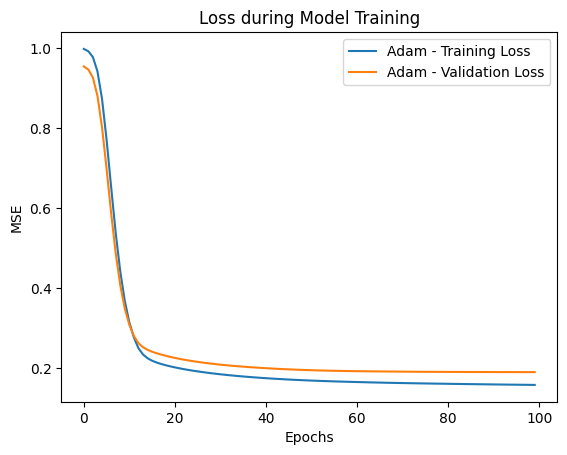

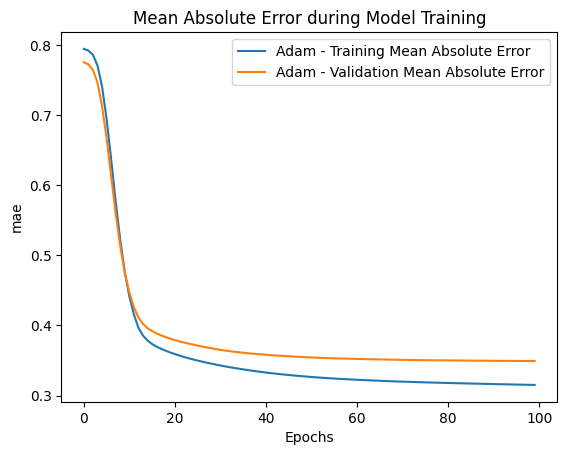

In [59]:



model_adam = Sequential([
    Input(shape=(35,)),
    Dense(16, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    Dense(16, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = Adam(learning_rate=0.0001)

model_adam.compile(
    optimizer=opt,
    loss="mse",
    metrics=['mae']
)

# Train the model using GD with train dataset and validate the model using validation dataset during training
start_time = time.time()

history_adam = model_adam.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time/60:.2f} minutes")

# Plot the training and validation accuracy and loss
plt.plot(history_adam.history["loss"], label="Adam - Training Loss")
plt.plot(history_adam.history["val_loss"], label="Adam - Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Loss during Model Training")
plt.legend()
plt.show()

plt.plot(history_adam.history["mae"], label="Adam - Training Mean Absolute Error")
plt.plot(history_adam.history["val_mae"], label="Adam - Validation Mean Absolute Error")
plt.xlabel("Epochs")
plt.ylabel("mae")
plt.title("Mean Absolute Error during Model Training")
plt.legend()
plt.show()

Evaluate suitable regularisation and generalisation techniques to reduce overfitting and improve model performance.

As shown above we can see that the model has no overfitting but to imrpove the performance of the model I will use early stopping to avoide any possible overfitting

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.9977 - mae: 0.7950 - val_loss: 0.9541 - val_mae: 0.7760
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9919 - mae: 0.7926 - val_loss: 0.9462 - val_mae: 0.7729
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9771 - mae: 0.7865 - val_loss: 0.9258 - val_mae: 0.7649
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9413 - mae: 0.7714 - val_loss: 0.8803 - val_mae: 0.7468
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8725 - mae: 0.7416 - val_loss: 0.8016 - val_mae: 0.7137
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7707 - mae: 0.6951 - val_loss: 0.6979 - val_mae: 0.6674
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6524 - mae: 0.6373 - val_loss: 0.5872 - val_mae: 0.6134
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5381 - mae: 0.5768 - val_loss: 0.4874 - val_mae: 0.5599
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.441

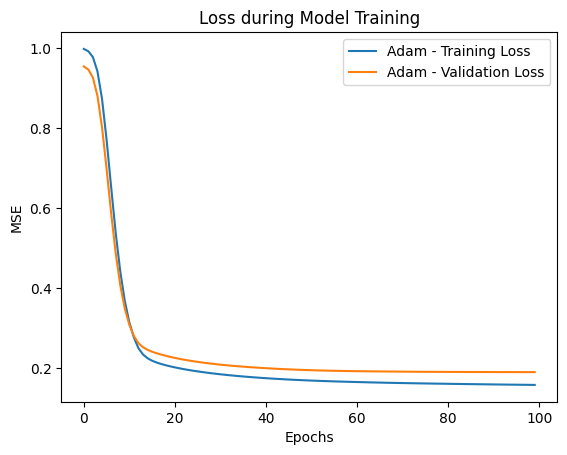

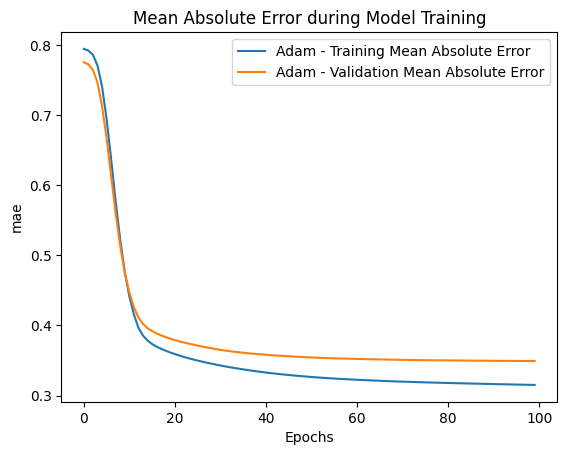

In [60]:
import keras


model_adam = Sequential([
    Input(shape=(35,)),
    Dense(16, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)), 
    Dense(16, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = Adam(learning_rate=0.0001)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)



model_adam.compile(
    optimizer=opt,
    loss="mse",
    metrics=['mae']
)

# Train the model using GD with train dataset and validate the model using validation dataset during training
start_time = time.time()

history_adam = model_adam.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1, 
    callbacks=[early_stop]
)

end_time = time.time()
training_time = end_time - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time/60:.2f} minutes")

# Plot the training and validation accuracy and loss
plt.plot(history_adam.history["loss"], label="Adam - Training Loss")
plt.plot(history_adam.history["val_loss"], label="Adam - Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Loss during Model Training")
plt.legend()
plt.show()

plt.plot(history_adam.history["mae"], label="Adam - Training Mean Absolute Error")
plt.plot(history_adam.history["val_mae"], label="Adam - Validation Mean Absolute Error")
plt.xlabel("Epochs")
plt.ylabel("mae")
plt.title("Mean Absolute Error during Model Training")
plt.legend()
plt.show()

Task 2.3 – Selection of the Final Model 
Using the findings in Tasks 2.2, develop your final regression model. 
Present the complete model specification including: 
• Number of hidden layers  
• Number of neurons in each layer 
• Activation functions  
• Optimiser  
• Learning rate  
• Batch size and number of epochs (or early stopping criterion, if used) 
• Regularisation techniques 
Support your architecture choices with evidence from your Task 2.2 experimental 
results, explaining why this configuration was selected over the alternatives tested.

So in the end, the model I choose is: 
• Number of hidden layers: 1 
• Number of neurons in each layer: 16
• Activation functions: relu 
• Optimiser: Adam
• Learning rate: 0.0001 
• Batch size and number of epochs (or early stopping criterion, if used): 32 and 100
• Regularisation techniques: early stopping 


Part 3 – Model Interpretation, Critical Evaluation and 
Professional Reporting (20 Marks) 
In this final section, you will evaluate the best-performing regression model developed 
in Task 2.3, and critically discuss its performance and limitations. All conclusions 
should be supported by evidence gathered throughout the assignment.  
Task 3.1 – Model Interpretation and Critical Evaluation 
1. Model Comparison 
Summarise the performance of the baseline and final models in Table 1, using your test 
set results, reported to an appropriate number of decimal places.

Here is the baseline model: 

In [63]:
from tensorflow.keras.metrics import RootMeanSquaredError, R2Score
### Gradient Descent

gd_model = Sequential([
    Input(shape=(35,)),
    Dense(32, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)), 
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = Adam(learning_rate=0.001)

gd_model.compile(
    optimizer=opt,
    loss="mse",
    metrics=["mae",   RootMeanSquaredError(name="rmse"),"r2_score"]
)


start_time = time.time()

# Train the model using GD with train dataset and validate the model using validation dataset during training
history_gd = gd_model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1
)

end_time = time.time()
gd_training_time = end_time - start_time

print(f"Training time: {gd_training_time:.2f} seconds")
print(f"Training time: {gd_training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6322 - mae: 0.6228 - r2_score: 0.3678 - rmse: 0.7951 - val_loss: 0.3011 - val_mae: 0.4434 - val_r2_score: 0.6852 - val_rmse: 0.5488
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2239 - mae: 0.3770 - r2_score: 0.7761 - rmse: 0.4731 - val_loss: 0.2174 - val_mae: 0.3725 - val_r2_score: 0.7728 - val_rmse: 0.4663
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1935 - mae: 0.3498 - r2_score: 0.8065 - rmse: 0.4398 - val_loss: 0.2062 - val_mae: 0.3629 - val_r2_score: 0.7845 - val_rmse: 0.4541
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1827 - mae: 0.3394 - r2_score: 0.8173 - rmse: 0.4274 - val_loss: 0.1987 - val_mae: 0.3564 - val_r2_score: 0.7923 - val_rmse: 0.4458
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1755 - mae: 0.3321 - r2_score: 0.8245 - rmse: 0.4189 - val_loss: 0.1941 - val_mae: 0.3526 - val_r2_score: 0.7971 - val_rmse: 0.4406
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━

Evaluate the baseline model using test data

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2071 - mae: 0.3589 - r2_score: 0.7989 - rmse: 0.4550 
Test baseline Loss : 0.2070656567811966
Test baseline MAE: 0.3588767945766449
Test baseline RMSE: 0.455044686794281
Test baseline r2_score: 0.7988944053649902


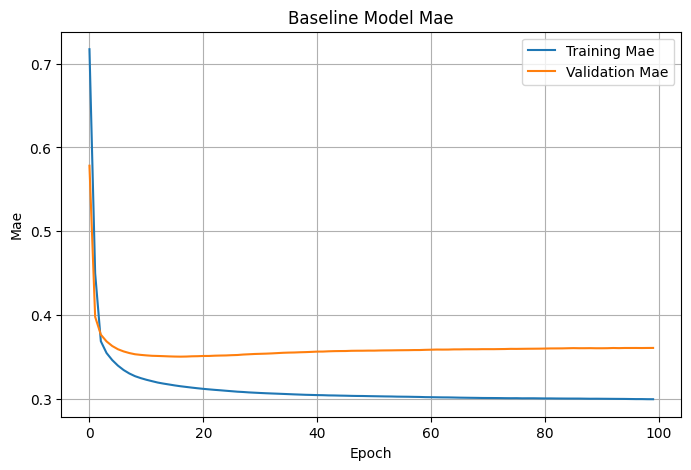

In [62]:
# Evaluate the Model
loss_baseline, mae_baseline, rmse_baseline, r2_score_baseline = gd_model.evaluate(
    X_test_scaled,
    y_test_scaled
)

print("Test baseline Loss :", loss_baseline)
print("Test baseline MAE:", mae_baseline)
print("Test baseline RMSE:", rmse_baseline)
print("Test baseline r2_score:", r2_score_baseline)

# Plot Training Mae
plt.figure(figsize=(8,5))
plt.plot(
    history_gd.history['mae'],
    label='Training Mae'
)
plt.plot(
    history_gd.history['val_mae'],
    label='Validation Mae'
)
plt.title("Baseline Model Mae")
plt.xlabel("Epoch")
plt.ylabel("Mae")
plt.legend()
plt.grid(True)
plt.show()

This is the improved model after tunninng. 

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9977 - mae: 0.7950 - r2_score: 0.0023 - rmse: 0.9989 - val_loss: 0.9541 - val_mae: 0.7760 - val_r2_score: 0.0028 - val_rmse: 0.9768
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9919 - mae: 0.7926 - r2_score: 0.0081 - rmse: 0.9959 - val_loss: 0.9462 - val_mae: 0.7729 - val_r2_score: 0.0110 - val_rmse: 0.9727
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9771 - mae: 0.7865 - r2_score: 0.0229 - rmse: 0.9885 - val_loss: 0.9258 - val_mae: 0.7649 - val_r2_score: 0.0323 - val_rmse: 0.9622
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9413 - mae: 0.7714 - r2_score: 0.0587 - rmse: 0.9702 - val_loss: 0.8803 - val_mae: 0.7468 - val_r2_score: 0.0798 - val_rmse: 0.9383
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8725 - mae: 0.7416 - r2_score: 0.1275 - rmse: 0.9341 - val_loss: 0.8016 - val_mae: 0.7137 - val_r2_score: 0.1621 - val_rmse: 0.8953
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━

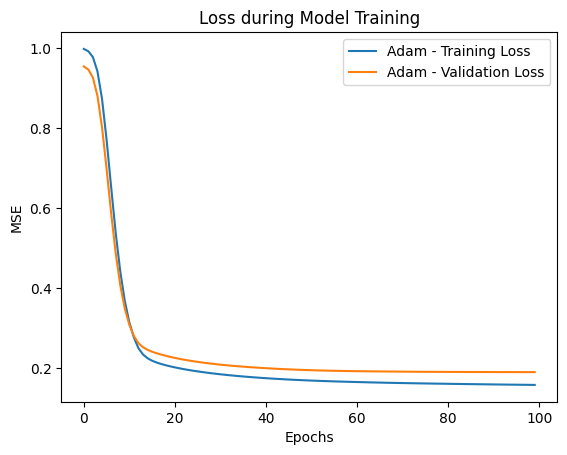

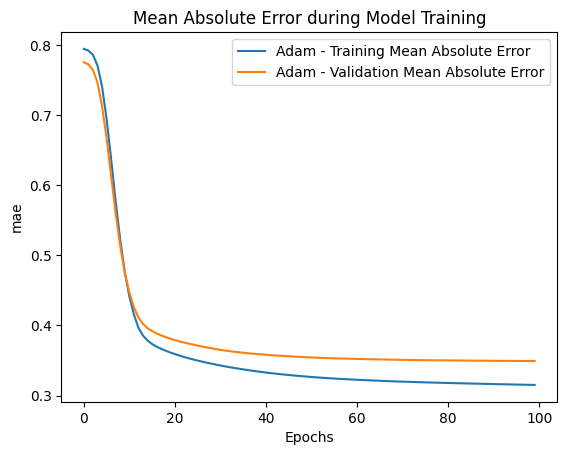

In [68]:
import keras


model_adam = Sequential([
    Input(shape=(35,)),
    Dense(16, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)), 
    Dense(16, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = Adam(learning_rate=0.0001)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)



model_adam.compile(
    optimizer=opt,
    loss="mse",
    metrics=['mae', RootMeanSquaredError(name="rmse"),"r2_score"]
)

# Train the model with train dataset and validate the model using validation dataset during training
start_time = time.time()

history_adam = model_adam.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1, 
    callbacks=[early_stop]
)

end_time = time.time()
training_time = end_time - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time/60:.2f} minutes")

# Plot the training and validation accuracy and loss
plt.plot(history_adam.history["loss"], label="Adam - Training Loss")
plt.plot(history_adam.history["val_loss"], label="Adam - Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Loss during Model Training")
plt.legend()
plt.show()

plt.plot(history_adam.history["mae"], label="Adam - Training Mean Absolute Error")
plt.plot(history_adam.history["val_mae"], label="Adam - Validation Mean Absolute Error")
plt.xlabel("Epochs")
plt.ylabel("mae")
plt.title("Mean Absolute Error during Model Training")
plt.legend()
plt.show()

And we use this improved model for the test data 

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1982 - mae: 0.3479 - r2_score: 0.8075 - rmse: 0.4452 
Test Improved model Loss : 0.1981678158044815
Test Improved model MAE: 0.347876638174057
Test Improved model RMSE: 0.445160448551178
Test Improved modelr2_score: 0.8075361251831055


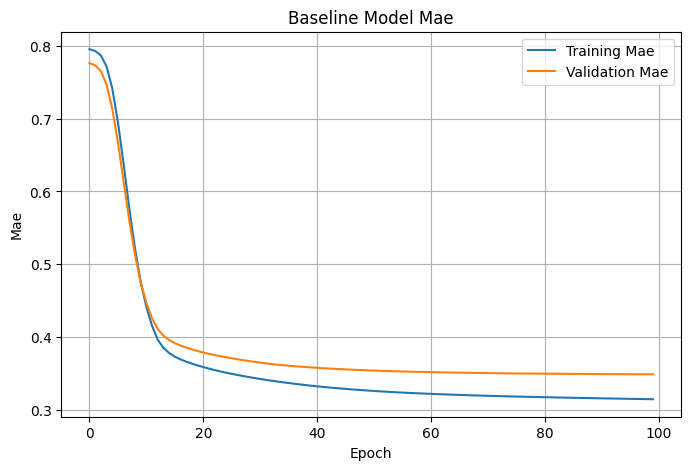

In [69]:
# Evaluate the Model
loss_improved, mae_improved, rmse_improved, r2_score_improved= model_adam.evaluate(
    X_test_scaled,
    y_test_scaled
)

print("Test Improved model Loss :", loss_improved)
print("Test Improved model MAE:", mae_improved)
print("Test Improved model RMSE:", rmse_improved)
print("Test Improved modelr2_score:", r2_score_improved)

# Plot Training Mae
plt.figure(figsize=(8,5))
plt.plot(
    history_adam.history['mae'],
    label='Training Mae'
)
plt.plot(
    history_adam.history['val_mae'],
    label='Validation Mae'
)
plt.title("Baseline Model Mae")
plt.xlabel("Epoch")
plt.ylabel("Mae")
plt.legend()
plt.grid(True)
plt.show()

In [70]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Baseline Model", "Improved model"],

    "MSE": [
        loss_baseline, loss_improved
       
    ],

   
    "MAE": [
        mae_baseline, mae_improved
               
    ],

    "RMSE": [
        rmse_baseline, rmse_improved
    ],

    
    "R2_Score": [
        r2_score_baseline, r2_score_improved
    ]})
comparison



,Model,MSE,MAE,RMSE,R2_Score
0,Baseline Model,0.207066,0.358877,0.455045,0.798894
1,Improved model,0.198168,0.347877,0.445160,0.807536


We save this result as a table 

In [71]:
comparison.to_csv(
    "model baseline_improve comparison.csv",
    index=False
)

2. Performance Discussion 
Using the results in Table 1 and any supporting plots (e.g., predicted vs. actual plot), 
discuss: 
• How accurately does the final model predict Soil Organic Carbon?  
• Has prediction accuracy improved compared with the baseline model?  
• Are prediction errors randomly distributed, or is there a pattern?  
• Are there specific observations or ranges that are consistently difficult to 
predict?

Based on the comparison between the baseline and improved model as shown above,
     Model	            MSE	        MAE	   RMSE	    R2_Score
0	Baseline Model	0.207066	0.358877	0.455045	0.798894
1	Improved model	0.198168	0.347877	0.445160	0.807536
 
 we can see that the final improved model slightly improve the prediction than the baseline mode. The model explain more than 81% the variation of the soil organic carbon

 The final model provide modest improvement from the baseline model, which shown in all the indicator, MSE slightly decrased from 0.20 to 0.18, MAE slighly decreased from 0.35 to 0.33, RMSE slightly decreased from 0.45 to 0.44 and R2_Score increased from 0.80 to 0.81




We will save the final model here 

In [72]:
model_adam.save("model_adam.keras")

3. Critical Evaluation 
Critically evaluate the strengths and limitations of your final deep learning model. Your 
discussion should address: 
• The contribution of key hyperparameters to model performance. 
• How overfitting was identified and addressed during model development.  

I think the strength of the final deep learning model is that accuracy of the model is high 81%. I think one of the strength of this model first came from the good baseline. Even though I checked the correlation in the EDA and identified that some variables have strong correlation with the target variable, when I tried to run the model based on only those variables (which I do not present in this codes), the R2_score of that model is quite low, just around 60% I think so I decided to use all the variables. With that, at the baseline model my R2_Score is already high 80%. I think a good baseline will be good starting point for the tuning later. 
I then tried to tuned the model by changing different parameters, such as the number of hidden layers, number of neuron, activation fuctions optimizers and their learning rates, and then identified an improved model. I think the good thing is I tried to tune the model in different ways, however, as I did it manually I might not catch the better combination of these hyperparameters so that my improved model can be improved more. In the end, my improve model just slightly improved than the baseline model (R2_score 81% vs 80%)
The overfitting was also identified by it is not much. Still I did the early stopping so that the model stop at its lowest loss and mae.